In [72]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
import os, os.path
import pandas as pd
import pathlib
import sisepuede.core.support_classes as sc
import sisepuede.manager.sisepuede_file_structure as sfs
import sisepuede.manager.sisepuede_models as sm
import sisepuede.utilities._toolbox as sf
import warnings
warnings.filterwarnings("ignore")

import utils.common_data_needs as cdn



# Initialize some SISEPUEDE components

In [2]:
dict_ssp = cdn._setup_sisepuede_elements()

matt = dict_ssp.get("model_attributes", )
models = dict_ssp.get("models", )
regions = dict_ssp.get("regions", )
time_periods = dict_ssp.get("time_periods", )

# setup region
_REGION_NAME = "uganda"
_REGION_ISO = regions.return_region_or_iso(_REGION_NAME, return_type = "iso")

# some fields
_FIELD_CENSUS = "pop_total_ubos"
_FIELD_POP_EST_MAX = "pop_est_max"
_FIELD_POP_EST_MIN = "pop_est_min"
_FIELD_POP_EST_NOMINAL = "pop_est_nominal"
_FIELD_POP_UN_MAX = "pop_un_max"
_FIELD_POP_UN_MIN = "pop_un_min"
_FIELD_POP_URBAN_BOS = "pop_urban_bos"
_FIELD_URBANIZATION_RATE = "frac_urban"
_FIELD_URBANIZATION_RATE_EST = "frac_urban_est"

# Build urban and rural populations

<Axes: xlabel='year'>

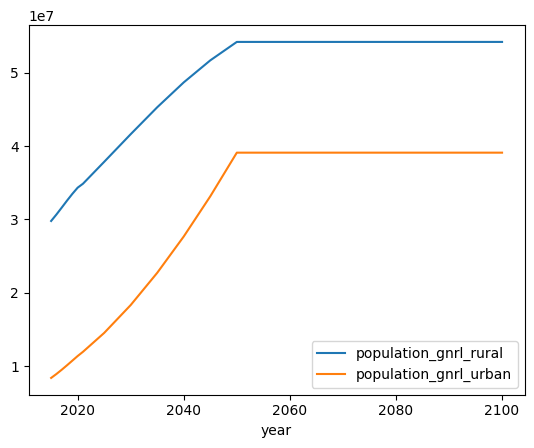

In [3]:
df_uganda = cdn.get_raw_ssp_inputs()

# get some SISEPUEDE info
attr_gnrl = matt.get_attribute_table(matt.subsec_name_gnrl)
modvar_pop = matt.get_variable(
    models.model_socioeconomic.modvar_gnrl_subpop,
)


(
    modvar_pop
    .get_from_dataframe(
        df_uganda, 
        fields_additional = [time_periods.field_year],
    )
    .plot(x = time_periods.field_year, )
)


# Adjust based off statistical abstract and census in 2014
- Census population from [Uganda BOS](https://www.ubos.org/explore-statistics/20/)

In [4]:
# get census data
fn_population_bos = "Census_Population_counts_(2002_and_2014)_by_Region,_District_and_Mid-Year_Population_projections_(2015-2021).xlsx"
path_pop = cdn._PATH_INPUTS.joinpath("ubos", fn_population_bos, )

# do some formatting
df_pop = pd.read_excel(path_pop, sheet_name = "Sheet3", skiprows = 4, )

# clean columns
vec_columns = list(df_pop.columns)
vec_columns[2] = str(df_pop.iloc[0, 2])
df_pop.columns = vec_columns

# drop
fields_drop = [
    x for x in df_pop.columns
    if (
        (
            isinstance(x, str) 
            and ("Unnamed" in x)
        )
        or (
            isinstance(x, int) 
            and x not in list(df_uganda[time_periods.field_year])
        )
    )
]


df_pop = (
    df_pop
    .drop(columns = fields_drop)
    .iloc[1:]
    .reset_index(drop = True, )
)

In [5]:
df_pop

,CENTRAL,2015,2016,2017,2018,2019,2020,2021
0,Kalangala,55900.0,58100.0,60300.0,62500.0,64800.0,67200.0,69500.0
1,Kampala,1529400.0,1559700.0,1590100.0,1620600.0,1650800.0,1680600.0,1709900.0
2,Kiboga,151200.0,155100.0,159100.0,163100.0,167100.0,171200.0,175200.0
3,Luwero,465500.0,476900.0,488500.0,500200.0,511900.0,523600.0,535200.0
4,Masaka,301900.0,308600.0,315400.0,322200.0,328900.0,335700.0,342300.0
...,...,...,...,...,...,...,...,...
134,Rukiga,101200.0,102100.0,103000.0,103800.0,104700.0,105400.0,106000.0
135,Rukungiri,317100.0,320500.0,324100.0,327400.0,330700.0,333800.0,336700.0
136,Rwampara,130000.0,132800.0,135800.0,138700.0,141600.0,144600.0,NaN
137,Sheema,209000.0,211400.0,213800.0,216100.0,218400.0,220500.0,222600.0


# Get the population from the census in a format that is comparable to Uganda data

In [145]:
df_pop_total_from_census = (
    df_pop[
        df_pop["CENTRAL"].isin(["National"])
    ]
    .drop(columns = ["CENTRAL"])
    .transpose()
    .reset_index()
)


# clean the names
field_to_rename = [x for x in df_pop_total_from_census.columns if x != "index"][0]

(
    df_pop_total_from_census
    .rename(
        columns = {
            "index": time_periods.field_year, 
            field_to_rename: _FIELD_CENSUS,
        },
        inplace = True,
    )
)


# ADD TWO VALUES FROM THE 2023 STATISTICAL ABSTRACT
#
# See FIGURE 2.1, PROJECTED POPULATION 2018-MID 2023
if False:
   
    df_pop_total_from_census_append = pd.DataFrame(
        {
            time_periods.field_year: [2022, 2023, 2024],
            _FIELD_CENSUS: [44200000, 45600000, 45900000]
        }
    )

"""
# ADD 2024 POPULATION COUNT
#
# See TABLE 2.3A IN https://www.ubos.org/wp-content/uploads/2024/12/National-Population-and-Housing-Census-2024-Final-Report-Volume-1-Main.pdf
df_pop_total_from_census_append = pd.DataFrame(
    {
        time_periods.field_year: [2024],
        _FIELD_CENSUS: [45905417]
    }
)


df_pop_total_from_census = (
    pd.concat(
        [
            df_pop_total_from_census,
            df_pop_total_from_census_append
        ]
    )
    .sort_values(by = [time_periods.field_year])
    .reset_index(drop = True, )
)
"""


# BUILD BASE POPULATION FROM CENSUS - average growth rates from Uganda Profile (pg xx)

gr_avg_2014 = 0.03
gr_avg_2024 = 0.029

y0, y1 = 2014, 2024
pop0 = 34600000
pop1 = 45905417

gr_const = (pop1/pop0)**(1/(y1 - y0))


pops = np.zeros(y1 - y0 + 1)
for i in range(pops.shape[0]):
    pops[i] = pop0*(gr_const**i)

pops = pops.astype(int)


#
df_pop_total_from_census = pd.DataFrame(
    {
        time_periods.field_year: range(y0, y1 + 1),
        _FIELD_CENSUS: pops,
    }
)




In [146]:
df_pop_total_from_census

,year,pop_total_ubos
0,2014,34600000
1,2015,35592204
2,2016,36612860
3,2017,37662786
4,2018,38742820
5,2019,39853825
6,2020,40996690
7,2021,42172328
8,2022,43381680
9,2023,44625711


# Use UN projections to 2100 to guide projections past 2040 (as well as shape to 2040)

In [153]:
path_un = pathlib.Path(
    "/Users/usuario/SISEPUEDE_DATA_REPOSITORY/UN/WPP2024_POP_F01_1_POPULATION_SINGLE_AGE_BOTH_SEXES.xlsx"
)
dict_un_table_names = pd.read_excel(
    path_un, 
    sheet_name = None, 
    nrows = 2,
)


# read in and filter
dict_un_tables = {}
fields_projections = []
field_un_year = "Year"
sheets_skip = ["NOTES"]

i = 0
for k in dict_un_table_names:
    if k in sheets_skip:
        continue
        
    df = pd.read_excel(
        path_un, 
        sheet_name = k, 
        skiprows = 16,
    )

    # filter
    df = df[
        df["ISO3 Alpha-code"].isin([_REGION_ISO])
    ]

    if len(df) == 0:
        continue

    # add the total population and extract
    fields_sum = [x for x in df.columns if str(x).isnumeric()] + ["100+"]
    df[k] = df[fields_sum].sum(axis = 1)
    
    df = (
        df[[field_un_year, k]]
        .rename(
            columns = {field_un_year: time_periods.field_year, }
        )
    )

    df[time_periods.field_year] = df[time_periods.field_year].astype(int)
    dict_un_tables.update({k: df, })
    fields_projections.append(k)

    print(f"Completed field {k}")
    
    # get total
    i += 1
    

Completed field Estimates
Completed field Medium variant
Completed field High variant
Completed field Low variant
Completed field Constant-fertility
Completed field Instant-replacement
Completed field Instant-replacement zero migr
Completed field Momentum
Completed field Zero-migration
Completed field Constant-mortality
Completed field No change
Completed field No fertility below age 18
Completed field Accelerated ABR decline
Completed field Accelarated ABR decline recup


In [154]:
dict_un_tables_safe = {}

for k, v in dict_un_tables.items():
    v2 = v.copy()
    dict_un_tables_safe.update({k: v2, })

In [155]:
# clean by adding estimates as base
key_base = "Estimates"
df_base = dict_un_tables.get(key_base)
dict_un_tables_new = {}

for k, v in dict_un_tables.items():

    # drop the stupid index
    v.reset_index(
        drop = True, 
        inplace = True, 
    )

    if k == key_base: continue

    # if missing, add in data from estimates
    df_prepend = (
        df_base[
            ~df_base[time_periods.field_year]
            .isin(v[time_periods.field_year].unique())
        ]
        .rename(columns = {key_base: k, })
    )

    v = (
        pd.concat(
            [df_prepend, v], 
            axis = 0, 
        )
        .sort_values(by = [time_periods.field_year])
        .reset_index(drop = True, )
    )
    
    dict_un_tables_new.update({k: v, })
    
dict_un_tables = dict_un_tables_new

##  Build a single df for UN projections so that we can get bounds

In [198]:
keys_un = list(dict_un_tables.keys())
df_un_projections = dict_un_tables.get(keys_un[0])

if len(keys_un) > 1:
    for k in keys_un[1:]:
        df_un_projections = pd.merge(
            df_un_projections, 
            dict_un_tables.get(k, ),
            how = "outer",
        )

# add bounds and multiply by 1000 to get real population
df_un_projections[keys_un] *= 1000 
df_un_projections[_FIELD_POP_UN_MAX] = df_un_projections[keys_un].max(axis = 1, )
df_un_projections[_FIELD_POP_UN_MIN] = df_un_projections[keys_un].min(axis = 1, )



# In UN projection data, get divergent year, then adjust if we have observations for it

In [199]:
# get the first divergent year
for i, row in df_un_projections.iterrows():
    if len(set(row[keys_un])) > 1:
        break

# get some information about when it diverges
y_divergent = row[time_periods.field_year]
i_divergent = i


if y_divergent in df_pop_total_from_census[time_periods.field_year].unique():
    df_tmp = pd.merge(
        df_pop_total_from_census,
        df_un_projections[
            df_un_projections[time_periods.field_year] >= y_divergent
        ],
        how = "inner",
    )

    # use mean
    fields_dat = [x for x in df_tmp.columns if x not in [time_periods.field_year, _FIELD_CENSUS]]
    mean = df_tmp[fields_dat].mean(axis = 1).to_numpy()

    # construct scalars to apply to un projections
    vec_avg_scale = (
        df_tmp[fields_dat]
        .to_numpy()
        .copy()
        .transpose()
    )
    
    vec_avg_scale /= mean
    vec_avg_scale = vec_avg_scale.mean(axis = 1)

    # update the values in df_un_projections to be "scaled" slightly to share mean
    for fld in fields_dat:
        df_tmp[fld] = mean

    df_un_projections_beyond = (
        df_un_projections[
            df_un_projections[time_periods.field_year] > df_tmp[time_periods.field_year].max()
        ]
    )

    df_un_projections_beyond[fields_dat] *= vec_avg_scale
    
    
    # now, rebuild
    df_un_projections = sf._concat_df(
        [
            df_un_projections[
                df_un_projections[time_periods.field_year] < df_tmp[time_periods.field_year].min()
            ],
            df_tmp.drop(columns = [_FIELD_CENSUS], ),
            df_un_projections_beyond
        ]
    ) 


    # UPDATE THE DIVERGENT YEAR
    #  
    for i, row in df_un_projections.iterrows():
        if len(set(row[keys_un])) > 1:
            break
    
    # get some information about when it diverges
    y_divergent = row[time_periods.field_year]
    i_divergent = i
    
    
    

# First, find a scalar to help align UN population projections with Uganda Census projections

In [200]:



df_un_projections_convergent = df_un_projections[
    df_un_projections[time_periods.field_year] < y_divergent
]

df_find_scalar = (
    pd.merge(
        df_un_projections_convergent[
            [
                time_periods.field_year,
                _FIELD_POP_UN_MAX,       # only need one field
            ]
        ],
        df_pop_total_from_census
    )
    .sort_values(by = [time_periods.field_year], )
)

# scale data to get best fit of UN to census estimates (NOT observations)
ratio_y0 = df_find_scalar[_FIELD_CENSUS].iloc[0]/df_find_scalar[_FIELD_POP_UN_MAX].iloc[0]
ratio_y1 = df_find_scalar[_FIELD_CENSUS].iloc[-1]/df_find_scalar[_FIELD_POP_UN_MAX].iloc[-1]
df_find_scalar["SCALAR"] = df_find_scalar[_FIELD_CENSUS].to_numpy()/df_find_scalar[_FIELD_POP_UN_MAX].to_numpy()
scale_factor_unpop = (ratio_y0 + ratio_y1)/2


# scale proportionally
df_un_projections0 = (
    pd.merge(
        df_un_projections,
        df_find_scalar[[time_periods.field_year, "SCALAR"]],
        how = "left",
    )
    .bfill()
    .ffill()
)


fields_scale = keys_un + [_FIELD_POP_UN_MIN, _FIELD_POP_UN_MAX]
arr_tmp = sf.do_array_mult(
    df_un_projections0[fields_scale].to_numpy(),
    df_un_projections0["SCALAR"].to_numpy()
)
    #*scale_factor_unpop
df_un_projections[fields_scale] = arr_tmp

#print(f"UN populations were scaled by {scale_factor_unpop}, average of {ratio_y0} and {ratio_y1}")

UN populations were scaled by 0.9351453914664208, average of 0.9506659724240649 and 0.9196248105087768


## Get information on divergence year and growth rates for each projection starting at that point

In [205]:


# get arrays of populations and growth rates for max/min
arr_pops = (
    df_un_projections[[_FIELD_POP_UN_MIN, _FIELD_POP_UN_MAX]]
    .iloc[i - 1:, :]
    .to_numpy()
)
arr_rates = arr_pops[1:]/arr_pops[0:-1]

# base vector to which growth rates are applied
vec_base_for_rates = df_un_projections[keys_un].iloc[i - 1].to_numpy()

In [206]:
(vec_base_for_rates[0] * np.cumprod(arr_rates, axis = 0))[16]

array([56497590.3669812, 74261446.7636333])

In [207]:
df_un_projections.iloc[i - 1]

year                                 2024.0
Medium variant                   45905417.0
High variant                     45905417.0
Low variant                      45905417.0
Constant-fertility               45905417.0
Instant-replacement              45905417.0
Instant-replacement zero migr    45905417.0
Momentum                         45905417.0
Zero-migration                   45905417.0
Constant-mortality               45905417.0
No change                        45905417.0
No fertility below age 18        45905417.0
Accelerated ABR decline          45905417.0
Accelarated ABR decline recup    45905417.0
pop_un_max                       45905417.0
pop_un_min                       45905417.0
Name: 74, dtype: float64

<Axes: xlabel='year'>

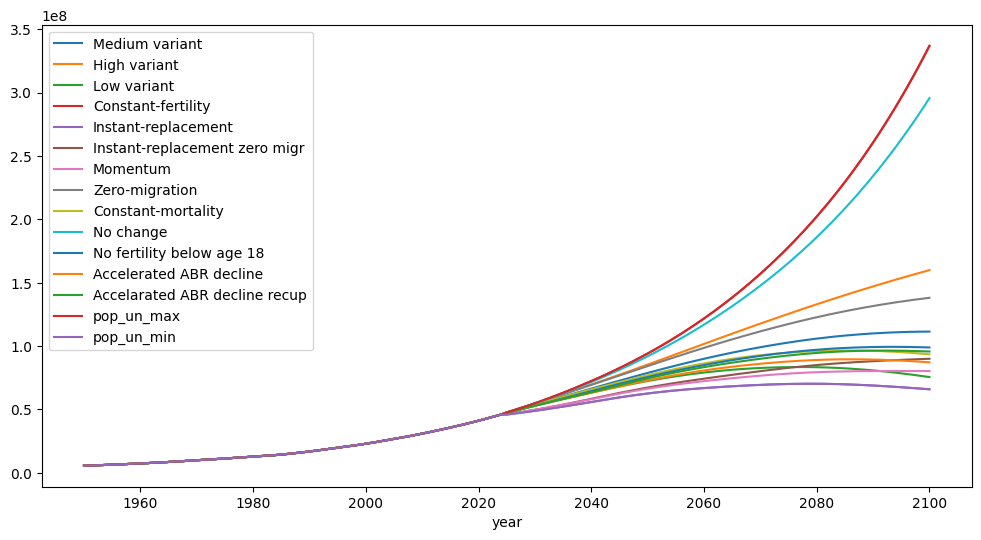

In [208]:
fig, ax = plt.subplots(figsize = (12, 6))
df_un_projections.plot(x = "year", ax = ax, )

# Now, we are going to search for populations
- NOTE: to hit the Vision 2040 high end population of 93.4 million, with a population of 45.6 million in 2023, the population would have to grow by 4.3%/year, higher than their original vision
- Furthermore, if we allow for the 3.2% growth rate from 2023 (based on current estimate of 45.6, we would find a total of 77,896,814--this is just below the UN top end projection of 73,048,952
    - We can scale up to meet this
- For the low end estimate of 61,000,000 (pg 88, paragraph 248 of Vision 2040), we find a mix between max and min that works
  

In [209]:
# scaled UN populations at 2040
series_un_2040 = df_un_projections[
    df_un_projections[time_periods.field_year].isin([2040])
].iloc[0]
series_un_2040

year                             2.040000e+03
Medium variant                   6.636119e+07
High variant                     6.950146e+07
Low variant                      6.323392e+07
Constant-fertility               7.225053e+07
Instant-replacement              5.574942e+07
Instant-replacement zero migr    5.827312e+07
Momentum                         5.799079e+07
Zero-migration                   6.924859e+07
Constant-mortality               6.571047e+07
No change                        7.151591e+07
No fertility below age 18        6.443927e+07
Accelerated ABR decline          6.302246e+07
Accelarated ABR decline recup    6.343737e+07
pop_un_max                       7.230321e+07
pop_un_min                       5.574942e+07
Name: 90, dtype: float64

In [210]:
# number of years for growth ests
n_years_exp = 2040 - y_divergent + 1
pop_last = (
    df_pop_total_from_census[
        df_pop_total_from_census[time_periods.field_year]
        .isin(
            [
                df_pop_total_from_census[time_periods.field_year].max()
            ]
        )
    ]
    .get(_FIELD_CENSUS)
    .iloc[0]
)
pop_last


np.int64(45905417)

In [211]:
# vision 2040 comparison to their own estimate
(93400000/pop_last)**(1/n_years_exp)




np.float64(1.0453944346290047)

##  Use 2.9% growth rate, as indicated in census instead of Vision 2040

In [212]:
val_2040_from_gr = pop_last*((1.029)**n_years_exp)   # 2024 to 2040--ind of UN data
val_2040_from_gr

np.float64(72528706.64115645)

In [213]:
# there's only one value in vec_base_for_rates, so we can pick an arbitrary element
ratio_top = val_2040_from_gr/series_un_2040[_FIELD_POP_UN_MAX]
scalar = ratio_top**(1/n_years_exp)


# ASSIGN TOP AND BOTTOM GROWTH RATES HERE
vec_max_gr = arr_rates[:, 1]*scalar
vec_min_gr = arr_rates[:, 0]

# verify this equivalience
np.round(vec_base_for_rates[0]*np.cumprod(vec_max_gr)[n_years_exp - 1] - val_2040_from_gr, decimals = 5)

np.float64(0.0)

## build a projection that aligns with 2040
- Use **Growth Rates** From Table 3.1 in NDPIV
    - Specify 2.7% by 2029/2030 (we set to 2030) and 2.4% by 2040
- Then, pick the UN population trajectory that most closely matches this one in 2041 (based on growth rate) and apply growth rates to generate nominal

In [341]:
_FIELD_GROWTH_SPECIFIED = "gr_specified"
_YEAR_2040 = 2040

##  SOME FUNCTIONS

if False:
    #
    #  OPTION TO BUILD GROWTH RATES HERE THAT ALIGN WITH 61000000 PERSON TARGET
    #
    
    def grs(
        delta: float,
        y_last: int, 
    ) -> np.ndarray:
        out = gr_const - np.arange(1, y_last + 1 - y1)*delta
        return out
    
    
        
    def est_pop(
        delta: float,
        y_last: int = _YEAR_2040,
    ) -> float:
        """Estimate the population using an annual reduction in 
            growth rate specified as delta
        """
    
        pop_est = pop_last*np.prod(grs(delta, y_last, ))
    
        return pop_est
    
    
    
    delta = 0.0013
    pop_targ = 61000000
    diff = 0.0000001
    pop_est = est_pop(delta, )
    
    i = 1
    while (pop_est < pop_targ):
        
        delta -= diff
        pop_est = est_pop(delta, )
    
        i += 1
    
        if (i > 10**6): break
    
    delta += diff
    
    df_growth = pd.DataFrame(
        {
            time_periods.field_year: range(y1, _YEAR_2040),
            _FIELD_GROWTH_SPECIFIED: grs(delta, _YEAR_2040)
        }
    )


##  OTHERWISE, USE GROWTH RATES FROM TABLE 3.1 OF NDP-IV

df_growth = (
    pd.merge(
        pd.DataFrame({time_periods.field_year: range(y1, _YEAR_2040 + 1)}),
        pd.DataFrame(
            {
                time_periods.field_year: [y1, 2030, _YEAR_2040],
                _FIELD_GROWTH_SPECIFIED: [gr_const, 1.027, 1.024]
            }
        ),
        how = "left",
    )
    .interpolate()
)




##  Now, pick the UN population trajectory with closest growth rate in 2041

In [356]:
# build UN population growth rates
fields_grs = keys_un + [_FIELD_POP_UN_MIN, _FIELD_POP_UN_MAX]
df_un_projection_grs = df_un_projections[fields_grs]
arr1 = df_un_projection_grs.to_numpy()[1:]
arr0 = df_un_projection_grs.to_numpy()[0:-1]

# 
df_un_projection_grs = pd.DataFrame(arr1/arr0, columns = fields_grs, )
df_un_projection_grs[time_periods.field_year] = df_un_projections[time_periods.field_year].iloc[0:-1]



year_gr_specified_max = df_growth[time_periods.field_year].max()
row_filt = df_un_projection_grs[
    df_un_projection_grs[time_periods.field_year]
    .isin([year_gr_specified_max])
].iloc[0]

# we know this is the min and is declining
gr_match = df_growth[_FIELD_GROWTH_SPECIFIED].min()
dist, fld = np.inf, ""

for k, v in row_filt.to_dict().items():
    if v > gr_match: continue

    dist_cand = np.abs(gr_match - v)
    if dist_cand < dist:
        fld = k
        dist = dist_cand
    
##  NOW, USE THOSE GROWTH RATES TO BUILD OUT NOMINAL

df_nominal = pd.concat(
    [
        df_growth[[time_periods.field_year, _FIELD_GROWTH_SPECIFIED]],
        (
            df_un_projection_grs[
                df_un_projection_grs[time_periods.field_year] > year_gr_specified_max
            ]
            .get([time_periods.field_year, fld])
            .rename(
                columns = {fld: _FIELD_GROWTH_SPECIFIED, }
            )
        )
    ]
)


##  BUILD POPULATION DF

df_pop_specified = pd.DataFrame(
    {
        time_periods.field_year: range(y1 + 1, df_nominal[time_periods.field_year].max() + 2),
        _FIELD_CENSUS: np.cumprod(df_nominal[_FIELD_GROWTH_SPECIFIED])*pop_last
    }
)


df_pop_specified = sf._concat_df(
    [
        df_pop_total_from_census,
        df_pop_specified
    ]
)

,Medium variant,High variant,Low variant,Constant-fertility,Instant-replacement,Instant-replacement zero migr,Momentum,Zero-migration,Constant-mortality,No change,No fertility below age 18,Accelerated ABR decline,Accelarated ABR decline recup,pop_un_min,pop_un_max,year
0,1.027865,1.027865,1.027865,1.027865,1.027865,1.027865,1.027865,1.027865,1.027865,1.027865,1.027865,1.027865,1.027865,1.027865,1.027865,1950
1,1.028061,1.028061,1.028061,1.028061,1.028061,1.028061,1.028061,1.028061,1.028061,1.028061,1.028061,1.028061,1.028061,1.028061,1.028061,1951
2,1.028368,1.028368,1.028368,1.028368,1.028368,1.028368,1.028368,1.028368,1.028368,1.028368,1.028368,1.028368,1.028368,1.028368,1.028368,1952
3,1.028633,1.028633,1.028633,1.028633,1.028633,1.028633,1.028633,1.028633,1.028633,1.028633,1.028633,1.028633,1.028633,1.028633,1.028633,1953
4,1.028840,1.028840,1.028840,1.028840,1.028840,1.028840,1.028840,1.028840,1.028840,1.028840,1.028840,1.028840,1.028840,1.028840,1.028840,1954
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,1.001187,1.008325,0.993089,1.026023,0.995494,1.002072,1.000010,1.004693,0.996997,1.023610,0.999507,0.997400,0.999167,0.995494,1.026023,2095
146,1.000890,1.008122,0.992627,1.026024,0.995190,1.001994,0.999987,1.004508,0.996639,1.023602,0.999198,0.997068,0.998878,0.995190,1.026024,2096
147,1.000694,1.007993,0.992308,1.026063,0.995055,1.001922,0.999971,1.004323,0.996402,1.023637,0.999002,0.996867,0.998707,0.995055,1.026063,2097
148,1.000544,1.007894,0.992056,1.026118,0.995009,1.001851,0.999959,1.004131,0.996222,1.023692,0.998859,0.996728,0.998592,0.995009,1.026118,2098


## Mix the min/max to hit 61,000,000 projection in 2040 

In [214]:
# number from Vision 2040, paragraph 248, pg 88
targ_low_2040 = 61000000

proj_max = vec_base_for_rates[0]*np.cumprod(vec_max_gr)[0:n_years_exp]
proj_min = vec_base_for_rates[0]*np.cumprod(vec_min_gr)[0:n_years_exp]

mix_0 = (targ_low_2040 - proj_min[-1])/(proj_max[-1] - proj_min[-1])

# get real mix value
def est_pop(
    mix: float,
) -> float:
    """
    """
    vec_lower_v2040 = vec_max_gr*mix + vec_min_gr*(1 - mix)
    out = vec_base_for_rates[0]*np.cumprod(vec_lower_v2040)[n_years_exp - 1]

    return out

# use bifurcation method
eps = 0.05
mix_1 = mix_0 + 0.05
pop_val = est_pop(mix_0, )

while np.abs(pop_val - targ_low_2040) > eps:
    mix_candidate = (mix_0 + mix_1)/2
    pop_val = est_pop(mix_candidate, )

    if pop_val > targ_low_2040:
        mix_1 = mix_candidate
    elif pop_val < targ_low_2040:
        mix_0 = mix_candidate
    else:
        print("breaking")
        break

# build the lower end val    
vec_gr_lower_v2040 = vec_max_gr*mix_candidate + vec_min_gr*(1 - mix_candidate) 

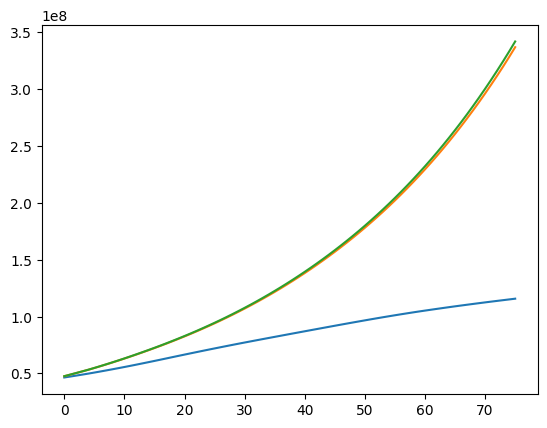

In [524]:
plt.plot(vec_base_for_rates[0]*np.cumprod(vec_gr_lower_v2040))
plt.plot(vec_base_for_rates[0]*np.cumprod(arr_rates[:,1]), )
plt.plot(vec_base_for_rates[0]*np.cumprod(vec_max_gr))

# Build DataFrame of total population projections
- We can use this to get bounds on total population
- As of Sep 15, Use specified population as nominal

In [555]:
pop_base = vec_base_for_rates[0]
vec_pop_max = pop_base*np.cumprod(vec_max_gr)#np.insert(np.cumprod(vec_max_gr), 0, 1.0, )
vec_pop_min = pop_base*np.cumprod(vec_min_gr)
#vec_pop_nominal = pop_base*np.cumprod(vec_gr_lower_v2040)
#vec_pop_nominal = df_pop_est
vec_pop_nominal = df_pop_specified[
    df_pop_specified[time_periods.field_year] > df_pop_total_from_census[time_periods.field_year].max()
][_FIELD_CENSUS].to_numpy()



### Now, build estimated population using min, max, nominal 

In [560]:

# rename
df_estimated_population = (
    df_un_projections
    .get(
        [
            time_periods.field_year,
            _FIELD_POP_UN_MIN,
            _FIELD_POP_UN_MAX,
        ]
    )
    .rename(
        columns = {
            _FIELD_POP_UN_MIN: _FIELD_POP_EST_MIN,
            _FIELD_POP_UN_MAX: _FIELD_POP_EST_MAX,
        }
    )
)

# 
df_estimated_population[_FIELD_POP_EST_NOMINAL] = df_estimated_population[_FIELD_POP_EST_MAX].copy()


# split and update divergent values
df_estimated_population_convergent = df_estimated_population[df_estimated_population[time_periods.field_year] < y_divergent]
df_estimated_population_divergent = df_estimated_population[df_estimated_population[time_periods.field_year] >= y_divergent]
df_estimated_population_divergent[_FIELD_POP_EST_MAX] = vec_pop_max
df_estimated_population_divergent[_FIELD_POP_EST_MIN] = vec_pop_min
df_estimated_population_divergent[_FIELD_POP_EST_NOMINAL] = vec_pop_nominal


df_estimated_population = (
    pd.concat(
        [
            df_estimated_population_convergent,
            df_estimated_population_divergent,
        ]
    )
    .sort_values(by = [time_periods.field_year])
    .reset_index(drop = True, )
)

<Axes: xlabel='year'>

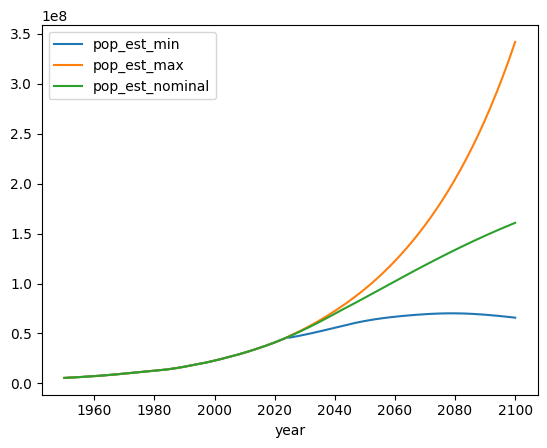

In [562]:
df_estimated_population.plot(x = time_periods.field_year, )

# Next, get urbanization estimates 

In [369]:
path_urbanization_un = pathlib.Path("/Users/usuario/SISEPUEDE_DATA_REPOSITORY/UN/WUP2018-F02-Proportion_Urban.xls")
if not path_urbanization_un.is_file():
    raise RuntimeError(f"UN Urbanization data at '{path_urbanization_un}' not found.")


In [377]:
df_urbanization_un = pd.read_excel(path_urbanization_un, skiprows = 16)
df_urbanization_un = df_urbanization_un[
    df_urbanization_un["Region, subregion, country or area"].isin(["Uganda"])
]

fields_keep = [x for x in df_urbanization_un.columns if str(x).isnumeric()]
df_urbanization_un = (
    df_urbanization_un[fields_keep]
    .transpose()
    .reset_index()
    .rename(
        columns = {"index": time_periods.field_year}
    )
)

# rename urbanization rate
_FIELD_URBANIZATION_RATE = "frac_urban"
field_rnm = [x for x in df_urbanization_un.columns if x != time_periods.field_year][0]
df_urbanization_un.rename(
    columns = {field_rnm: _FIELD_URBANIZATION_RATE, },
    inplace = True,
)

# convert to frac instead of percentage
df_urbanization_un[_FIELD_URBANIZATION_RATE] /= 100


###  The statistical abstract for 2023 has urban populations, which we can use to estimate urbanization rates in historical years
- Use **Figure 2.3: Urban Population by Census Year and Projection** (page 81, 2023 BOS Statistical Abstract)
- Use Table 11.4 in Census to BACK OUT Urban v rural (use avg hh size per type)

In [389]:
hh_size_rural = 4.5
hh_size_urban = 3.8
hh_size_national = 4.2

# hh_size_national = frac_rural*hh_size_rural + (1 - frac_rural)*hh_size_urban
# frac_rural(hh_size_rural - hh_size_urban) + hh_size_urban = hh_size_national
frac_rural = (hh_size_national - hh_size_urban)/(hh_size_rural - hh_size_urban)

# hh_rural*hh_size_rural + 
frac_urban = 1 - frac_rural
int(frac_urban*pop_last)

19673750

In [391]:
df_pop_urban_bos = pd.DataFrame(
    {
        time_periods.field_year: [2014, 2020, 2021, 2022, 2023, 2024],
        _FIELD_POP_URBAN_BOS: [7.4, 10.6, 11.4, 16.5, 17, frac_urban*pop_last/1000000]      
    }
)

df_pop_urban_bos[_FIELD_POP_URBAN_BOS] *= 1000000
df_pop_urban_bos


,year,pop_urban_bos
0,2014,7.400000e+06
1,2020,1.060000e+07
2,2021,1.140000e+07
3,2022,1.650000e+07
4,2023,1.700000e+07
5,2024,1.967375e+07


In [591]:
df_urbanization_rates = pd.merge(
    df_estimated_population
    .get(
        [
            time_periods.field_year,
            _FIELD_POP_EST_NOMINAL
        ]
    ),
    df_pop_urban_bos,
    how = "left"
)

# merge and fill
df_urbanization_rates = (
    df_urbanization_rates[
        df_urbanization_rates[time_periods.field_year]
        .isin(
            range(
                df_pop_urban_bos[time_periods.field_year].min(),
                df_pop_urban_bos[time_periods.field_year].max() + 1,
            )
        )
    ]
    .interpolate()
)

# get estimated urbanization rate
df_urbanization_rates[_FIELD_URBANIZATION_RATE_EST] = (
    df_urbanization_rates[_FIELD_POP_URBAN_BOS]/df_urbanization_rates[_FIELD_POP_EST_NOMINAL]
)



df_urbanization_rates = sf._concat_df(
    [
        (
            df_urbanization_un[
                df_urbanization_un[time_periods.field_year] < df_urbanization_rates[time_periods.field_year].min()
            ]
            .get(
                [time_periods.field_year, _FIELD_URBANIZATION_RATE]
            )
            .rename(
                columns = {_FIELD_URBANIZATION_RATE: _FIELD_URBANIZATION_RATE_EST}
            )
        ),
        df_urbanization_rates
        .get(
            [time_periods.field_year, _FIELD_URBANIZATION_RATE_EST]    
        )
    ]
)


<Axes: xlabel='year'>

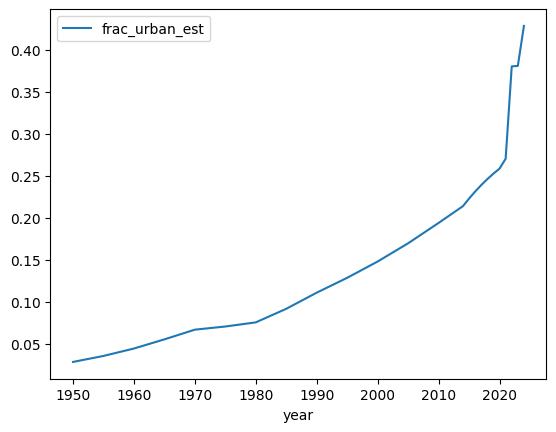

In [592]:
df_urbanization_rates.plot(x = "year", y = _FIELD_URBANIZATION_RATE_EST)

## Combine UN estimates of urbanization with UBOS estimates to generate a base case for urbanization rates




<Axes: xlabel='year'>

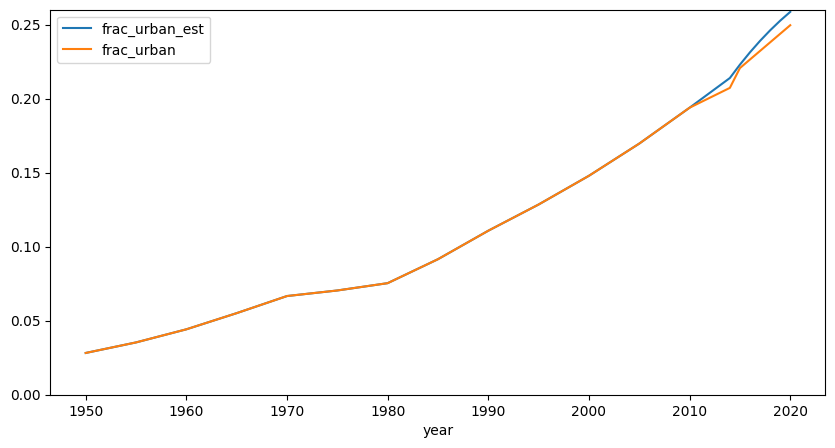

In [593]:
df_urbaniation_est = (
    pd.merge(
        df_urbanization_rates
        .get(
            [
                time_periods.field_year,
                _FIELD_URBANIZATION_RATE_EST
            ]
        ),
        df_urbanization_un,
        how = "left",
    )
    .sort_values(by = [time_periods.field_year], )
    .interpolate(limit_area = "inside", )
    .dropna()
    .reset_index(drop = True, )
)


# look a comparison of the urbanization rates (very similar)
fig, ax = plt.subplots(figsize = (10, 5))
ax.set_ylim((0, 0.26))
df_urbaniation_est.plot(x = "year", ax = ax, )

##  DEPRECATED: Similarly to population, use a ratio between UN and UBOS to adjust UN


In [420]:

# scale data to get best fit of UN to census estimates (NOT observations)
ratio_y0_ur = df_urbaniation_est[_FIELD_URBANIZATION_RATE_EST].iloc[0]/df_urbaniation_est[_FIELD_URBANIZATION_RATE].iloc[0]
ratio_y1_ur = df_urbaniation_est[_FIELD_URBANIZATION_RATE_EST].iloc[-1]/df_urbaniation_est[_FIELD_URBANIZATION_RATE].iloc[-1]
scale_factor_un_ur = (2*ratio_y0_ur + 4*ratio_y1_ur)/6


# adjust
df_urbanization_adj = df_urbaniation_est.copy()
df_urbanization_adj[_FIELD_URBANIZATION_RATE] *= scale_factor_un_ur

<Axes: xlabel='year'>

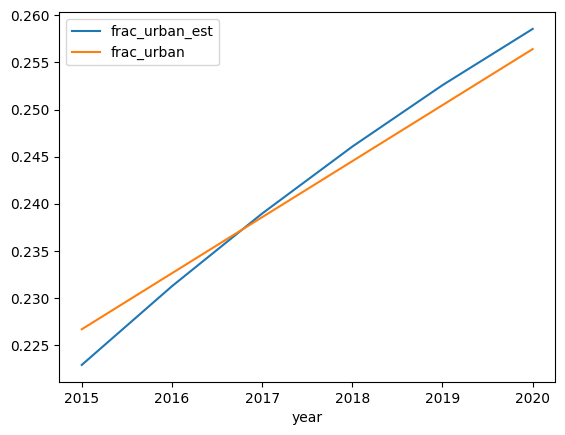

In [422]:
df_urbanization_adj.plot(x = time_periods.field_year, )

# Second Approach (LATEST): Scale up urbanization rates from UN


In [594]:
field_year = time_periods.field_year

# get years to merge to
y_0_urb = df_urbanization_un[
    df_urbanization_un[field_year] < df_urbanization_rates[field_year].max()
][field_year].max()

y_1_urb = df_urbanization_un[
    df_urbanization_un[field_year] > df_urbanization_rates[field_year].max()
][field_year].min()

df_urbanization_un_tmp = (
    pd.merge(
        pd.DataFrame({field_year: range(y_0_urb, y_1_urb + 1)}),
        df_urbanization_un,
        how = "left",
    )
    .interpolate()
)


## NEXT, GET VALUES TO MATCH

df_urb_scalar = pd.merge(
    df_urbanization_un_tmp,
    df_urbanization_rates,
    how = "inner",
)

series_urb_scalar = df_urb_scalar[
    df_urb_scalar[field_year]
    .isin([df_urb_scalar[field_year].max()])
]

diff = float(
    series_urb_scalar[_FIELD_URBANIZATION_RATE_EST] - series_urb_scalar[_FIELD_URBANIZATION_RATE]
)


##  ADD TO UN URB RATES AND CONCAT
df_urbanization_adj = df_urbanization_un[
    df_urbanization_un[field_year] > df_urbanization_rates[field_year].max()
]
df_urbanization_adj[_FIELD_URBANIZATION_RATE] += diff


df_urbanization_adj = sf._concat_df(
    [
        df_urbanization_rates[[field_year, _FIELD_URBANIZATION_RATE_EST]]
        .rename(columns = {_FIELD_URBANIZATION_RATE_EST: _FIELD_URBANIZATION_RATE, }),
        df_urbanization_adj
    ]
)


##  GET AVERAGE URB RATE PER 10 YEARS

urb_2050 = (
    df_urbanization_adj[
        df_urbanization_adj[field_year].isin([2050])
    ]
    .iloc[0]
    .get(_FIELD_URBANIZATION_RATE)
)

urb_2040 = (
    df_urbanization_adj[
        df_urbanization_adj[field_year].isin([2040])
    ]
    .iloc[0]
    .get(_FIELD_URBANIZATION_RATE)
)

delta_urb = urb_2050 - urb_2040

delta_urb_2100 = delta_urb*5
urb_2100 = delta_urb_2100 + urb_2050


if 2100 not in df_urbanization_adj[field_year].unique():
    df_urbanization_adj = sf._concat_df(
        [
            df_urbanization_adj,
            pd.DataFrame(
                {
                    field_year: [2100],
                    _FIELD_URBANIZATION_RATE: [urb_2100]
                }
            )
        ]
    )

# do an estimation of urbanization rates beyond 2050
- project to 2100 sing spline--we only care about up to 2070


<Axes: xlabel='year'>

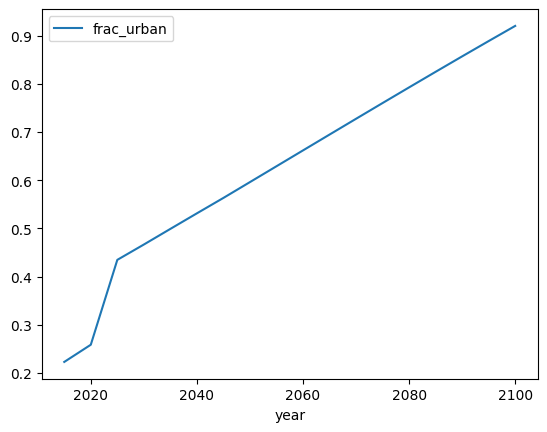

In [568]:
# project to 2100 
df_urbanization_adj = (
    pd.merge(
        pd.DataFrame(
            {
                time_periods.field_year: 1950 + np.arange(31)*5
            }
        ),
        df_urbanization_adj,
        how = "left",
    )
    .interpolate(
        method = "cubic", 
        limit_direction = "forward", 
        order = 3,
    )
)

# verify visually
df_urbanization_adj.plot(x = time_periods.field_year, )

##  Finally, for each population trajectory, get the est urban/rural pop

In [569]:
# build a data frame for easier interpolation
df_est = (
    pd.merge(
        df_estimated_population,
        df_urbanization_adj,
        how = "left", 
    )
    .interpolate() # fill in those missing 5-year periods
)


#
fields_pop = [
    _FIELD_POP_EST_MAX,
    _FIELD_POP_EST_MIN,
    _FIELD_POP_EST_NOMINAL,
]

# split for urban and rural
df_est_urban = df_est.copy()
df_est_rural = df_est.copy()
dfs = [df_est_urban, df_est_rural]

for i, df in enumerate(dfs):
    
    arr = df[fields_pop].to_numpy().transpose()

    # get multiplier
    vec = df[_FIELD_URBANIZATION_RATE].to_numpy()
    vec = 1 - vec if i == 1 else vec

    df[fields_pop] = (arr*vec).transpose().astype(int)


# set sisepuede cats
field_cat = matt.get_subsector_attribute("General", "pycategory_primary_element")
df_est_rural[field_cat] = modvar_pop.build_fields(category_restrictions = "rural")
df_est_urban[field_cat] = modvar_pop.build_fields(category_restrictions = "urban")

df_est = pd.concat([df_est_rural, df_est_urban])


    

# Finally, set output variable for pop and build outputs
- can be used to build other trajectories and explore around population 

In [570]:
_FIELD_POP_BUILD = _FIELD_POP_EST_NOMINAL

df_piv = df_est[[time_periods.field_year, _FIELD_POP_BUILD, field_cat]]
df_piv = (
    df_piv
    .pivot(
        columns = field_cat,
        index = time_periods.field_year,
        values = _FIELD_POP_BUILD
    )
    .reset_index()
)

df_piv.columns.name = None


<Axes: xlabel='year', ylabel='Population (10 millions)'>

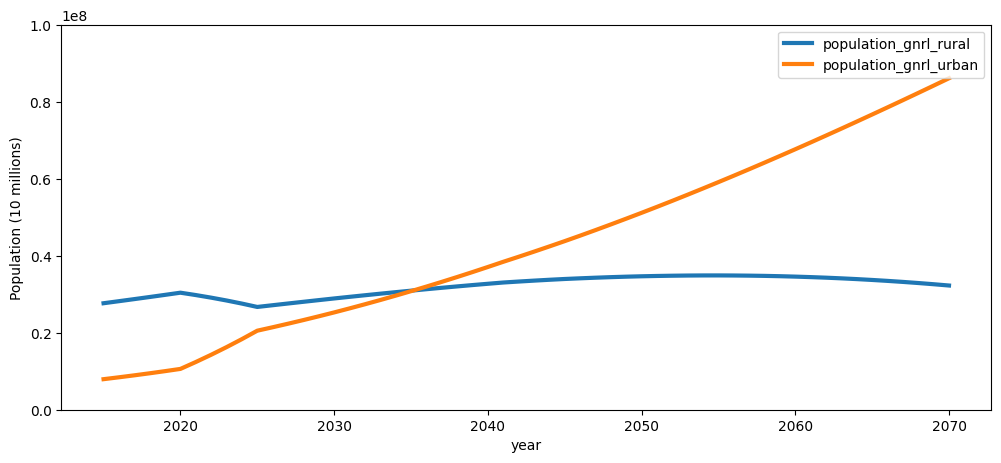

In [573]:
fig, ax = plt.subplots(figsize = (12, 5))
ax.set_ylim(0, 100000000)
ax.set_ylabel("Population (10 millions)")
ax.set_xlabel("Year")

(
    df_piv[
        df_piv[time_periods.field_year].isin(range(2015, 2071))
    ]
    .plot(
        x = time_periods.field_year, 
        ax = ax, 
        linewidth = 3,
    )
)

# Export

In [574]:
df_piv.to_csv(
    cdn._PATH_OUTPUTS.joinpath(f"{modvar_pop.name.upper()}.csv"),
    encoding = "UTF-8",
    index = None, 
)